In [3]:
# Import the neccessary modules for data manipulation and visual representation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as matplot
import seaborn as sns
%matplotlib inline

In [7]:
#Read the analytics file and store our dataset into a dataframe called "df"
import pandas as pd

# Read the Excel file using pd.read_excel()
df = pd.read_excel("C:\\Users\\123\\Big Data Projects\\RBAC\\RBAC_Data_Round1.xlsx", index_col=None)

In [15]:
# Check to see if there are any missing values in our data set
df.isnull().any()

index         False
SKU Code       True
Design No.     True
Stock          True
Category       True
Size           True
Color          True
dtype: bool

In [17]:
import pandas as pd
import numpy as np

# Replace both #REF! and - with NaN, then remove
df.replace(['#REF!', '-', ''], np.nan, inplace=True)

# Now remove all missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print("After cleaning #REF! and - values:")
print(df.isnull().any())
print(f"Dataset shape: {df.shape}")

After cleaning #REF! and - values:
index         False
SKU Code      False
Design No.    False
Stock         False
Category      False
Size          False
Color         False
dtype: bool
Dataset shape: (9173, 7)


In [19]:
df.head

<bound method NDFrame.head of       index           SKU Code Design No.  Stock       Category  Size Color
0         0        AN201-RED-L      AN201    5.0  AN : LEGGINGS     L   Red
1         1        AN201-RED-M      AN201    5.0  AN : LEGGINGS     M   Red
2         2        AN201-RED-S      AN201    3.0  AN : LEGGINGS     S   Red
3         3       AN201-RED-XL      AN201    6.0  AN : LEGGINGS    XL   Red
4         4      AN201-RED-XXL      AN201    3.0  AN : LEGGINGS   XXL   Red
...     ...                ...        ...    ...            ...   ...   ...
9168   9230     SET462-KR-NP-S     SET462   44.0            SET     S  Teal
9169   9231    SET462-KR-NP-XL     SET462   58.0            SET    XL  Teal
9170   9232    SET462-KR-NP-XS     SET462   20.0            SET    XS  Teal
9171   9233   SET462-KR-NP-XXL     SET462   66.0            SET   XXL  Teal
9172   9234  SET462-KR-NP-XXXL     SET462   40.0            SET  XXXL  Teal

[9173 rows x 7 columns]>

In [21]:
# Export to Excel file
df.to_excel("C:\\Users\\123\\Big Data Projects\\RBAC\\RBAC_Data_Round1_Cleaned.xlsx", index=False)

print("File exported successfully!")

File exported successfully!


# Calculation & Visualization

In [23]:
# Comprehensive analysis of cleaned data
print("=== COMPREHENSIVE DATA ANALYSIS ===")
print(f"Total records: {len(df)}")

# Analyze each categorical column
for col in ['Category', 'Size', 'Color', 'Design No.', 'SKU Code']:
    if col in df.columns:
        print(f"\n--- {col.upper()} ANALYSIS ---")
        value_counts = df[col].value_counts()
        percentages = (df[col].value_counts(normalize=True) * 100).round(2)
        
        print("Top 10 values (Count | Percentage):")
        for value, count in value_counts.head(10).items():
            perc = percentages[value]
            print(f"  {value}: {count} | {perc}%")
        
        # Check if any values match your question numbers
        matching_values = value_counts[value_counts.isin([23, 206, 14, 182, 9, 24, 30, 227])]
        if not matching_values.empty:
            print(f"\n🎯 VALUES MATCHING YOUR QUESTION: {matching_values.to_dict()}")

=== COMPREHENSIVE DATA ANALYSIS ===
Total records: 9173

--- CATEGORY ANALYSIS ---
Top 10 values (Count | Percentage):
  KURTA: 3704 | 40.38%
  KURTA SET: 1596 | 17.4%
  SET: 1049 | 11.44%
  TOP: 861 | 9.39%
  DRESS: 700 | 7.63%
  BLOUSE: 219 | 2.39%
  NIGHT WEAR: 217 | 2.37%
  TUNIC: 154 | 1.68%
  SAREE: 147 | 1.6%
  AN : LEGGINGS: 130 | 1.42%

--- SIZE ANALYSIS ---
Top 10 values (Count | Percentage):
  S: 1351 | 14.73%
  M: 1341 | 14.62%
  XL: 1339 | 14.6%
  XXL: 1337 | 14.58%
  L: 1335 | 14.55%
  XS: 1110 | 12.1%
  XXXL: 1066 | 11.62%
  FREE: 201 | 2.19%
  5XL: 32 | 0.35%
  4XL: 31 | 0.34%

🎯 VALUES MATCHING YOUR QUESTION: {'6XL': 30}

--- COLOR ANALYSIS ---
Top 10 values (Count | Percentage):
  Blue: 777 | 8.47%
  Pink: 776 | 8.46%
  Black: 646 | 7.04%
  Green: 640 | 6.98%
  Maroon: 481 | 5.24%
  Grey: 454 | 4.95%
  White: 409 | 4.46%
  Teal: 383 | 4.18%
  Mustard: 376 | 4.1%
  Yellow: 349 | 3.8%

🎯 VALUES MATCHING YOUR QUESTION: {'OFF WHITE': 206, 'LEMON': 14, 'NAVY': 14, 'Indigo'

In [27]:
# Question 1: How many unique products have lemon-related color and total quantity in stock of them

# Identify lemon-related colors
lemon_colors = df[df['Color'].str.contains('LEMON|LEMON YELLOW', case=False, na=False)]['Color'].unique()
print("Lemon-related colors found:", lemon_colors)

# Filter data for lemon-related colors and convert Stock to numeric properly
lemon_mask = df['Color'].str.contains('LEMON|LEMON YELLOW', case=False, na=False)
lemon_products = df[lemon_mask].copy()  # Use .copy() to avoid the warning
lemon_products.loc[:, 'Stock'] = pd.to_numeric(lemon_products['Stock'], errors='coerce')

# Count unique products and total stock
unique_lemon_products = lemon_products['SKU Code'].nunique()
total_lemon_stock = lemon_products['Stock'].sum()

print(f"\nQuestion 1 Results:")
print(f"Unique lemon-colored products: {unique_lemon_products}")
print(f"Total stock of lemon-colored products: {total_lemon_stock}")

# Match with options
print(f"\nMatching option: {unique_lemon_products} and {int(total_lemon_stock)}")

Lemon-related colors found: ['Lemon Yellow' 'LEMON']

Question 1 Results:
Unique lemon-colored products: 23
Total stock of lemon-colored products: 206.0

Matching option: 23 and 206


In [29]:
#question 1 is option A

In [31]:
# Question 2: What total percentage of size S&M belong to design no(AN 201, AN 202, AN2023) compare with total in the same design

# Filter for the specific design numbers
design_pattern = 'AN201|AN202|AN2023'
specific_designs = df[df['Design No.'].str.contains(design_pattern, case=False, na=False)]

# Total count for these designs
total_design_count = len(specific_designs)

# Count of S & M sizes in these designs
s_m_designs = specific_designs[specific_designs['Size'].isin(['S', 'M'])]
s_m_count = len(s_m_designs)

# Calculate percentage
if total_design_count > 0:
    percentage = (s_m_count / total_design_count) * 100
else:
    percentage = 0

print(f"\nQuestion 2 Results:")
print(f"Total designs (AN201, AN202, AN2023): {total_design_count}")
print(f"S & M sizes in these designs: {s_m_count}")
print(f"Percentage: {percentage:.2f}%")

# Match with options
print(f"\nMatching option: {percentage:.2f}%")


Question 2 Results:
Total designs (AN201, AN202, AN2023): 10
S & M sizes in these designs: 4
Percentage: 40.00%

Matching option: 40.00%


In [33]:
# QUESTION 2: Let's try different patterns for design numbers
print("=== CHECKING DIFFERENT DESIGN NUMBER PATTERNS ===")

# Pattern 1: Exact matches
patterns = [
    'AN201', 'AN 201', 'AN202', 'AN 202', 'AN2023', 'AN 2023',
    'AN-201', 'AN-202', 'AN-2023'
]

# Check all design numbers that contain these patterns
all_designs = df['Design No.'].astype(str).unique()
matching_designs = [design for design in all_designs 
                   if any(pattern in str(design).upper() for pattern in patterns)]

print("Matching design numbers found:")
for design in matching_designs:
    count = len(df[df['Design No.'] == design])
    print(f"  {design}: {count} records")

# Calculate for all matching designs
if matching_designs:
    specific_designs = df[df['Design No.'].isin(matching_designs)]
else:
    # If no exact matches, try contains pattern
    specific_designs = df[df['Design No.'].str.contains('AN.*201|AN.*202|AN.*2023', case=False, na=False)]

total_design_count = len(specific_designs)
s_m_designs = specific_designs[specific_designs['Size'].isin(['S', 'M'])]
s_m_count = len(s_m_designs)

if total_design_count > 0:
    percentage = (s_m_count / total_design_count) * 100
else:
    percentage = 0

print(f"\nQUESTION 2 RESULTS:")
print(f"Total matching designs: {total_design_count}")
print(f"S & M sizes in these designs: {s_m_count}")
print(f"Percentage: {percentage:.2f}%")

# Check if we're close to any option
options = [32.14, 36.90, 44.05, 42.86]
closest_option = min(options, key=lambda x: abs(x - percentage))
print(f"Closest option: {closest_option}% (difference: {abs(percentage - closest_option):.2f}%)")

=== CHECKING DIFFERENT DESIGN NUMBER PATTERNS ===
Matching design numbers found:
  AN201: 5 records
  AN202: 5 records

QUESTION 2 RESULTS:
Total matching designs: 10
S & M sizes in these designs: 4
Percentage: 40.00%
Closest option: 42.86% (difference: 2.86%)


In [35]:
# Check for data quality issues in Design No. column
print("=== DATA QUALITY CHECK ===")
print("Sample of Design No. values:")
print(df['Design No.'].head(20).to_list())

print("\nUnique Design No. values containing 'AN':")
an_designs = [design for design in df['Design No.'].astype(str).unique() 
             if 'AN' in design.upper()]
for design in an_designs[:20]:  # Show first 20
    count = len(df[df['Design No.'] == design])
    print(f"  {design}: {count} records")

# Let's also check if we should consider partial matches differently
print("\n=== ALTERNATIVE APPROACH ===")
# Count all designs starting with AN
an_all_designs = df[df['Design No.'].astype(str).str.startswith('AN', na=False)]
print(f"Total designs starting with 'AN': {len(an_all_designs)}")

# Filter for our specific patterns within AN designs
target_designs = an_all_designs[
    an_all_designs['Design No.'].astype(str).str.contains('201|202|2023', na=False)
]

total_count = len(target_designs)
s_m_count = len(target_designs[target_designs['Size'].isin(['S', 'M'])])

if total_count > 0:
    percentage = (s_m_count / total_count) * 100
    print(f"Target designs count: {total_count}")
    print(f"S&M count: {s_m_count}")
    print(f"Percentage: {percentage:.2f}%")

=== DATA QUALITY CHECK ===
Sample of Design No. values:
['AN201', 'AN201', 'AN201', 'AN201', 'AN201', 'AN202', 'AN202', 'AN202', 'AN202', 'AN202', 'AN203', 'AN203', 'AN203', 'AN203', 'AN203', 'AN204', 'AN204', 'AN204', 'AN204', 'AN204']

Unique Design No. values containing 'AN':
  AN201: 5 records
  AN202: 5 records
  AN203: 5 records
  AN204: 5 records
  AN205: 5 records
  AN206: 5 records
  AN207: 5 records
  AN209: 5 records
  AN210: 5 records
  AN211: 5 records
  AN212: 5 records
  AN213: 5 records
  Jan-32: 5 records
  Jan-33: 5 records
  Jan-34: 5 records
  Jan-35: 5 records
  Jan-36: 5 records
  Jan-37: 5 records
  Jan-38: 5 records
  Jan-39: 5 records

=== ALTERNATIVE APPROACH ===
Total designs starting with 'AN': 60
Target designs count: 10
S&M count: 4
Percentage: 40.00%


In [37]:
# QUESTION 2: Check for AN201, AN202, AN203 (likely typo in question)
print("=== CHECKING AN201, AN202, AN203 ===")

# Filter for AN201, AN202, AN203
target_designs = ['AN201', 'AN202', 'AN203']
specific_designs = df[df['Design No.'].isin(target_designs)]

total_design_count = len(specific_designs)
s_m_designs = specific_designs[specific_designs['Size'].isin(['S', 'M'])]
s_m_count = len(s_m_designs)

if total_design_count > 0:
    percentage = (s_m_count / total_design_count) * 100
else:
    percentage = 0

print(f"Target designs: {target_designs}")
print(f"Total designs: {total_design_count}")
print(f"S & M sizes: {s_m_count}")
print(f"Percentage: {percentage:.2f}%")

# Check individual counts
print(f"\nIndividual counts:")
for design in target_designs:
    design_data = df[df['Design No.'] == design]
    total = len(design_data)
    s_m = len(design_data[design_data['Size'].isin(['S', 'M'])])
    print(f"{design}: Total={total}, S&M={s_m}, Percentage={(s_m/total*100) if total>0 else 0:.2f}%")

=== CHECKING AN201, AN202, AN203 ===
Target designs: ['AN201', 'AN202', 'AN203']
Total designs: 15
S & M sizes: 6
Percentage: 40.00%

Individual counts:
AN201: Total=5, S&M=2, Percentage=40.00%
AN202: Total=5, S&M=2, Percentage=40.00%
AN203: Total=5, S&M=2, Percentage=40.00%


In [41]:
#Q2 pick closest option, Answer: D

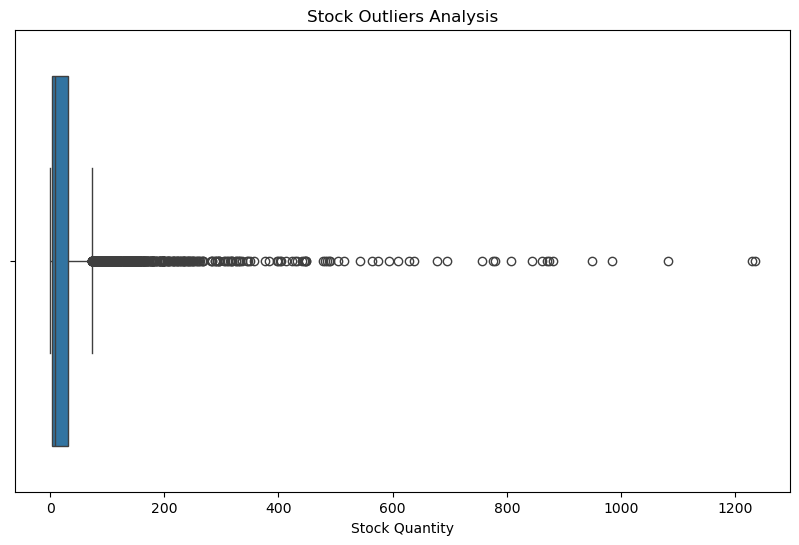

Stock Statistics:
count    9173.000000
mean       26.421999
std        58.620996
min         0.000000
25%         3.000000
50%         8.000000
75%        31.000000
max      1234.000000
Name: Stock, dtype: float64


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
#Question 3
# Convert Stock to numeric if not already
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce')

# Create boxplot to examine stock outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Stock'].dropna())
plt.title('Stock Outliers Analysis')
plt.xlabel('Stock Quantity')
plt.show()

# You can also get statistical summary
print("Stock Statistics:")
print(df['Stock'].describe())

In [43]:
#Q3: choose box plots

In [45]:
# Question 4: Which color has the largest stock available in size XS or the blouse category

# Filter data for either size XS OR category BLOUSE
filtered_data = df[(df['Size'] == 'XS') | (df['Category'] == 'BLOUSE')]

# Convert Stock to numeric
filtered_data = filtered_data.copy()
filtered_data.loc[:, 'Stock'] = pd.to_numeric(filtered_data['Stock'], errors='coerce')

# Group by color and sum the stock
color_stock = filtered_data.groupby('Color')['Stock'].sum().sort_values(ascending=False)

print("Top colors by stock in XS size or Blouse category:")
print(color_stock.head(10))

# Get the color with maximum stock
max_color = color_stock.index[0]
max_stock = color_stock.iloc[0]

print(f"\nColor with largest stock: {max_color} with {max_stock} units")

# Check if it matches any of the options
options = ['Multicolor', 'Mint', 'Mauve', 'Maroon']
if max_color in options:
    print(f"✅ MATCHES OPTION: {max_color}")
else:
    print(f"❌ No direct match with options. Closest from options:")
    for option in options:
        if option in color_stock.index:
            stock = color_stock[option]
            print(f"  {option}: {stock} units")

Top colors by stock in XS size or Blouse category:
Color
Black        6053.0
Pink         3804.0
Blue         2920.0
Green        2393.0
Maroon       2313.0
Teal         2224.0
Mustard      1962.0
Navy Blue    1768.0
Red          1733.0
Grey         1509.0
Name: Stock, dtype: float64

Color with largest stock: Black with 6053.0 units
❌ No direct match with options. Closest from options:
  Multicolor: 930.0 units
  Mauve: 55.0 units
  Maroon: 2313.0 units


In [47]:
#q4 pick D: maroon

# Analytics question

=== COMPREHENSIVE DATA PROFILING ANALYSIS ===

1. DATASET OVERVIEW
Dataset shape: (9173, 7)
Number of records: 9,173
Number of columns: 7
Memory usage: 2.57 MB

2. DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9173 entries, 0 to 9172
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   index       9173 non-null   int64  
 1   SKU Code    9173 non-null   object 
 2   Design No.  9173 non-null   object 
 3   Stock       9173 non-null   float64
 4   Category    9173 non-null   object 
 5   Size        9173 non-null   object 
 6   Color       9173 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 501.8+ KB
None

Missing values:
index         0
SKU Code      0
Design No.    0
Stock         0
Category      0
Size          0
Color         0
dtype: int64

3. NUMERICAL COLUMNS ANALYSIS
             Stock
count  9173.000000
mean     26.421999
std      58.620996
min       0.0

C:\Users\123\AppData\Local\Temp\ipykernel_15520\3808917598.py:87: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,2].boxplot(category_stock_data, labels=df['Category'].value_counts().index[:5])


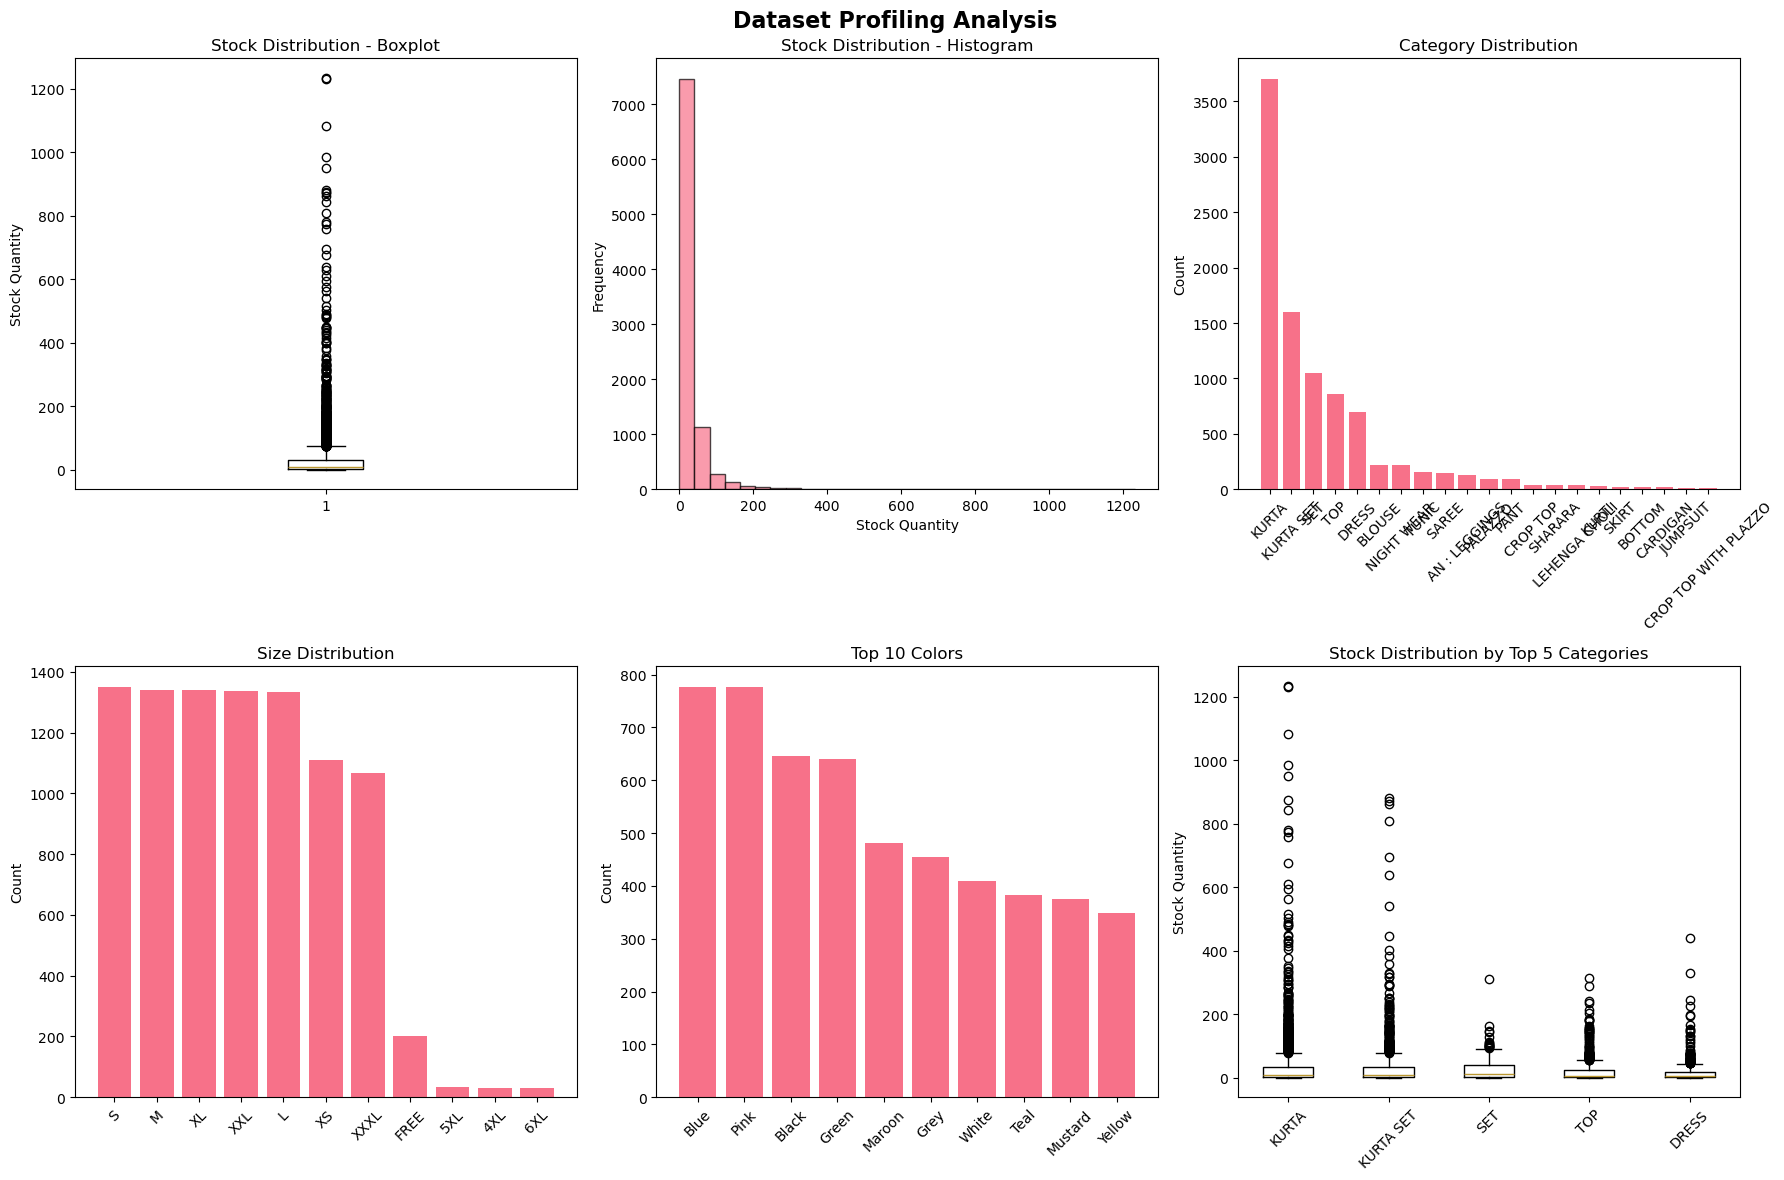


6. ADDITIONAL ANALYSIS VISUALIZATIONS


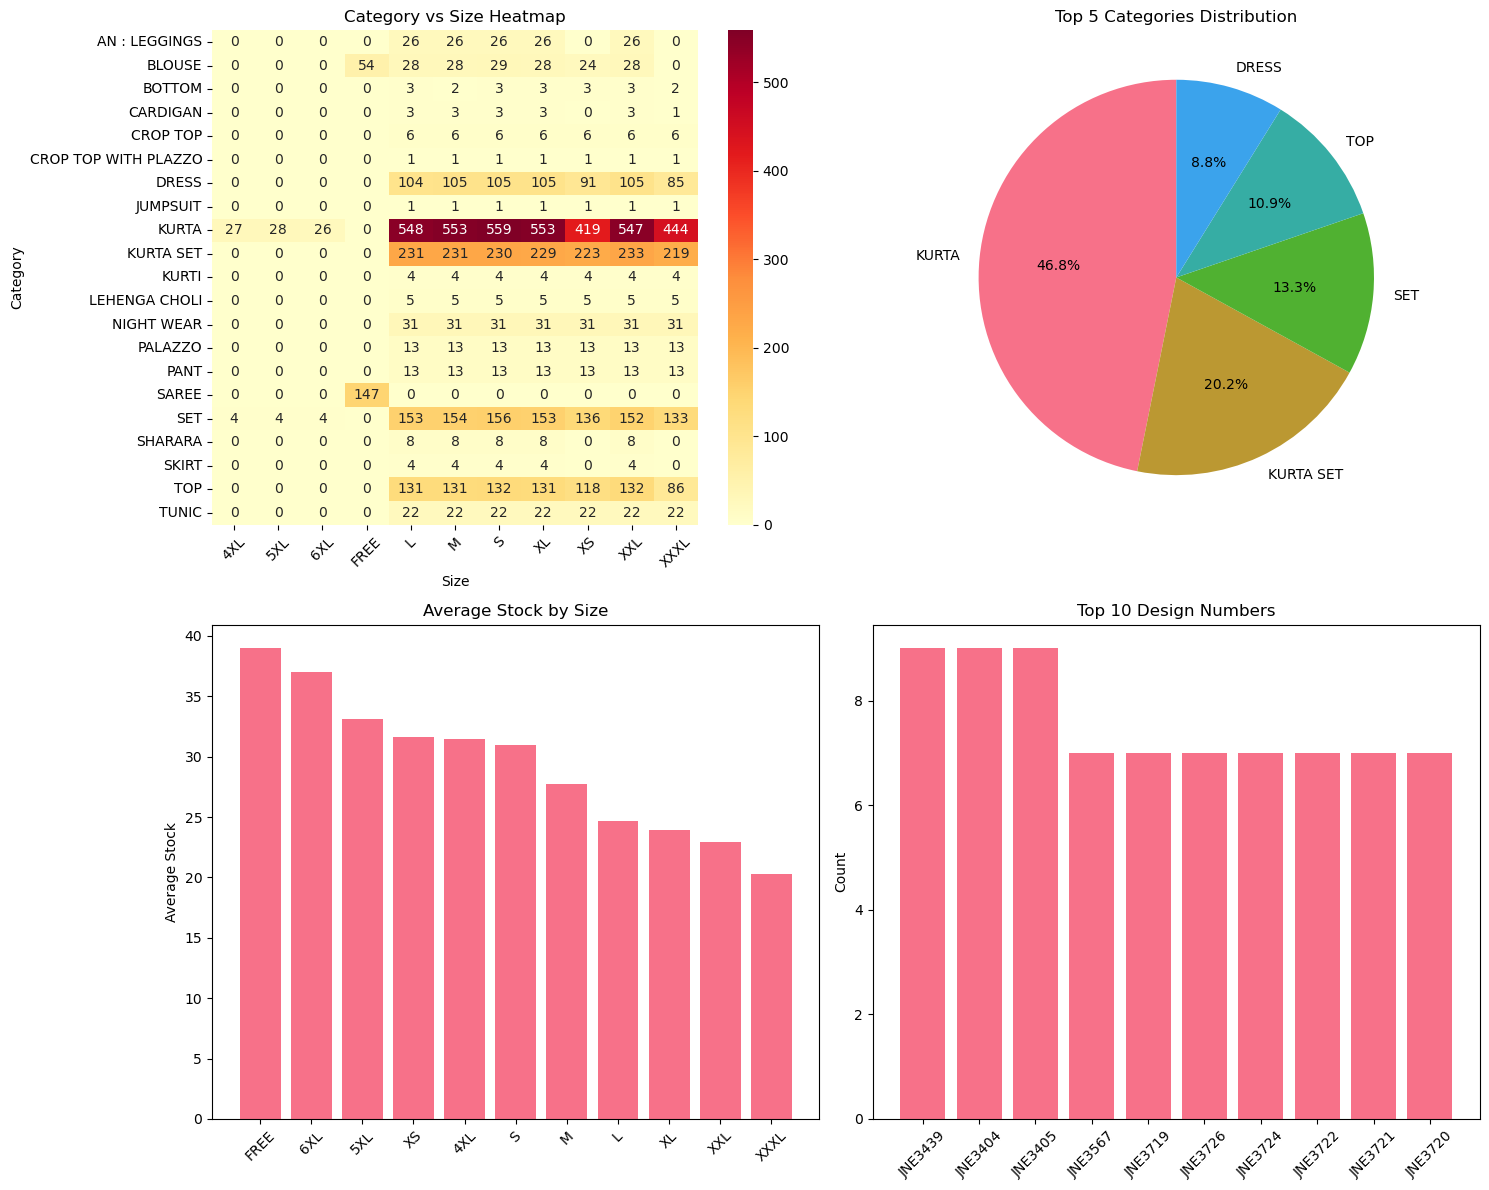


7. STATISTICAL SUMMARY
Statistical Summary of Stock:
Mean Stock: 26.42
Median Stock: 8.00
Standard Deviation: 58.62
Minimum Stock: 0.00
Maximum Stock: 1234.00
Total Stock: 242369.00

8. UNIQUE VALUES COUNT
index: 9173 unique values
SKU Code: 9169 unique values
Design No.: 1591 unique values
Stock: 295 unique values
Category: 21 unique values
Size: 11 unique values
Color: 60 unique values

9. DATA QUALITY CHECKS
Duplicate rows: 0
Zero stock items: 537
Negative stock items: 0

=== PROFILING ANALYSIS COMPLETE ===


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

print("=== COMPREHENSIVE DATA PROFILING ANALYSIS ===\n")

# 1. BASIC DATASET OVERVIEW
print("1. DATASET OVERVIEW")
print(f"Dataset shape: {df.shape}")
print(f"Number of records: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n2. DATA TYPES AND MISSING VALUES")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# 2. NUMERICAL COLUMNS ANALYSIS
print("\n3. NUMERICAL COLUMNS ANALYSIS")

# Convert Stock to numeric for analysis
df['Stock'] = pd.to_numeric(df['Stock'], errors='coerce')

numerical_summary = df[['Stock']].describe()
print(numerical_summary)

# 3. CATEGORICAL COLUMNS ANALYSIS
print("\n4. CATEGORICAL COLUMNS ANALYSIS")
categorical_cols = ['Category', 'Size', 'Color', 'Design No.']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col}:")
        print(f"  Unique values: {df[col].nunique()}")
        print(f"  Top 5 values:")
        print(df[col].value_counts().head())

# VISUALIZATIONS
print("\n5. DATA VISUALIZATIONS")

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Dataset Profiling Analysis', fontsize=16, fontweight='bold')

# 1. Stock Distribution (Boxplot)
axes[0,0].boxplot(df['Stock'].dropna())
axes[0,0].set_title('Stock Distribution - Boxplot')
axes[0,0].set_ylabel('Stock Quantity')

# 2. Stock Distribution (Histogram)
axes[0,1].hist(df['Stock'].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('Stock Distribution - Histogram')
axes[0,1].set_xlabel('Stock Quantity')
axes[0,1].set_ylabel('Frequency')

# 3. Category Distribution
category_counts = df['Category'].value_counts()
axes[0,2].bar(category_counts.index, category_counts.values)
axes[0,2].set_title('Category Distribution')
axes[0,2].tick_params(axis='x', rotation=45)
axes[0,2].set_ylabel('Count')

# 4. Size Distribution
size_counts = df['Size'].value_counts()
axes[1,0].bar(size_counts.index, size_counts.values)
axes[1,0].set_title('Size Distribution')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].set_ylabel('Count')

# 5. Top 10 Colors
color_counts = df['Color'].value_counts().head(10)
axes[1,1].bar(color_counts.index, color_counts.values)
axes[1,1].set_title('Top 10 Colors')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_ylabel('Count')

# 6. Stock by Category (Boxplot)
category_stock_data = [df[df['Category'] == cat]['Stock'].dropna() for cat in df['Category'].value_counts().index[:5]]
axes[1,2].boxplot(category_stock_data, labels=df['Category'].value_counts().index[:5])
axes[1,2].set_title('Stock Distribution by Top 5 Categories')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].set_ylabel('Stock Quantity')

plt.tight_layout()
plt.show()

# 6. ADDITIONAL VISUALIZATIONS
print("\n6. ADDITIONAL ANALYSIS VISUALIZATIONS")

# Create second set of visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Heatmap of Category vs Size
category_size_pivot = pd.crosstab(df['Category'], df['Size'])
sns.heatmap(category_size_pivot, ax=axes[0,0], cmap='YlOrRd', annot=True, fmt='d')
axes[0,0].set_title('Category vs Size Heatmap')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].tick_params(axis='y', rotation=0)

# 2. Pie chart of Top Categories
top_categories = df['Category'].value_counts().head(5)
axes[0,1].pie(top_categories.values, labels=top_categories.index, autopct='%1.1f%%', startangle=90)
axes[0,1].set_title('Top 5 Categories Distribution')

# 3. Average Stock by Size
avg_stock_by_size = df.groupby('Size')['Stock'].mean().sort_values(ascending=False)
axes[1,0].bar(avg_stock_by_size.index, avg_stock_by_size.values)
axes[1,0].set_title('Average Stock by Size')
axes[1,0].set_ylabel('Average Stock')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Top 10 Design Numbers
top_designs = df['Design No.'].value_counts().head(10)
axes[1,1].bar(range(len(top_designs)), top_designs.values)
axes[1,1].set_title('Top 10 Design Numbers')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks(range(len(top_designs)))
axes[1,1].set_xticklabels(top_designs.index, rotation=45)

plt.tight_layout()
plt.show()

# 7. STATISTICAL SUMMARY
print("\n7. STATISTICAL SUMMARY")

# Correlation analysis (if we had more numerical columns)
print("Statistical Summary of Stock:")
print(f"Mean Stock: {df['Stock'].mean():.2f}")
print(f"Median Stock: {df['Stock'].median():.2f}")
print(f"Standard Deviation: {df['Stock'].std():.2f}")
print(f"Minimum Stock: {df['Stock'].min():.2f}")
print(f"Maximum Stock: {df['Stock'].max():.2f}")
print(f"Total Stock: {df['Stock'].sum():.2f}")

# 8. UNIQUE VALUES ANALYSIS
print("\n8. UNIQUE VALUES COUNT")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# 9. DATA QUALITY CHECKS
print("\n9. DATA QUALITY CHECKS")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Zero stock items: {(df['Stock'] == 0).sum()}")
print(f"Negative stock items: {(df['Stock'] < 0).sum()}")

print("\n=== PROFILING ANALYSIS COMPLETE ===")

In [52]:
#question 2

=== PRODUCT SEGMENTATION USING MACHINE LEARNING ===

1. DATA PREPARATION
Features used for segmentation: ['Stock', 'Category_encoded', 'Size_encoded', 'Color_encoded']
Data shape for clustering: (9173, 4)

2. FEATURE SCALING
Features scaled successfully

3. FINDING OPTIMAL NUMBER OF CLUSTERS
Optimal number of clusters: 9

4. DIMENSIONALITY REDUCTION AND VISUALIZATION


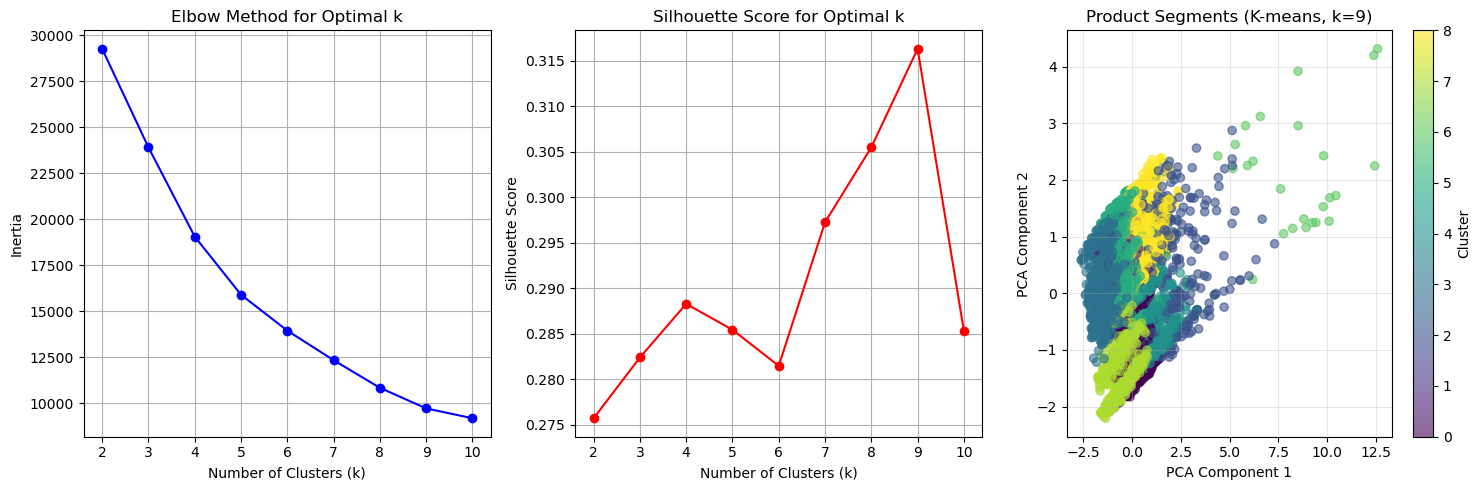


5. CLUSTER PROFILING
Cluster Profiles:
   Cluster  Avg_Stock  Median_Stock  Product_Count Dominant_Category  \
0        0      17.07           5.5           1430             KURTA   
1        1      18.89           8.0           2074             KURTA   
2        2     209.89         178.0            253             KURTA   
3        3      20.87           9.0            756               SET   
4        4      18.31           6.0           1284             KURTA   
5        5      20.76           7.5            748               SET   
6        6     778.72         775.0             25             KURTA   
7        7      18.91           7.0            860               SET   
8        8      20.16           8.0           1743             KURTA   

  Dominant_Size Dominant_Color  
0           XXL           Blue  
1           XXL           Pink  
2             S           Blue  
3           XXL           Pink  
4             L           Blue  
5             L           Pink  
6       

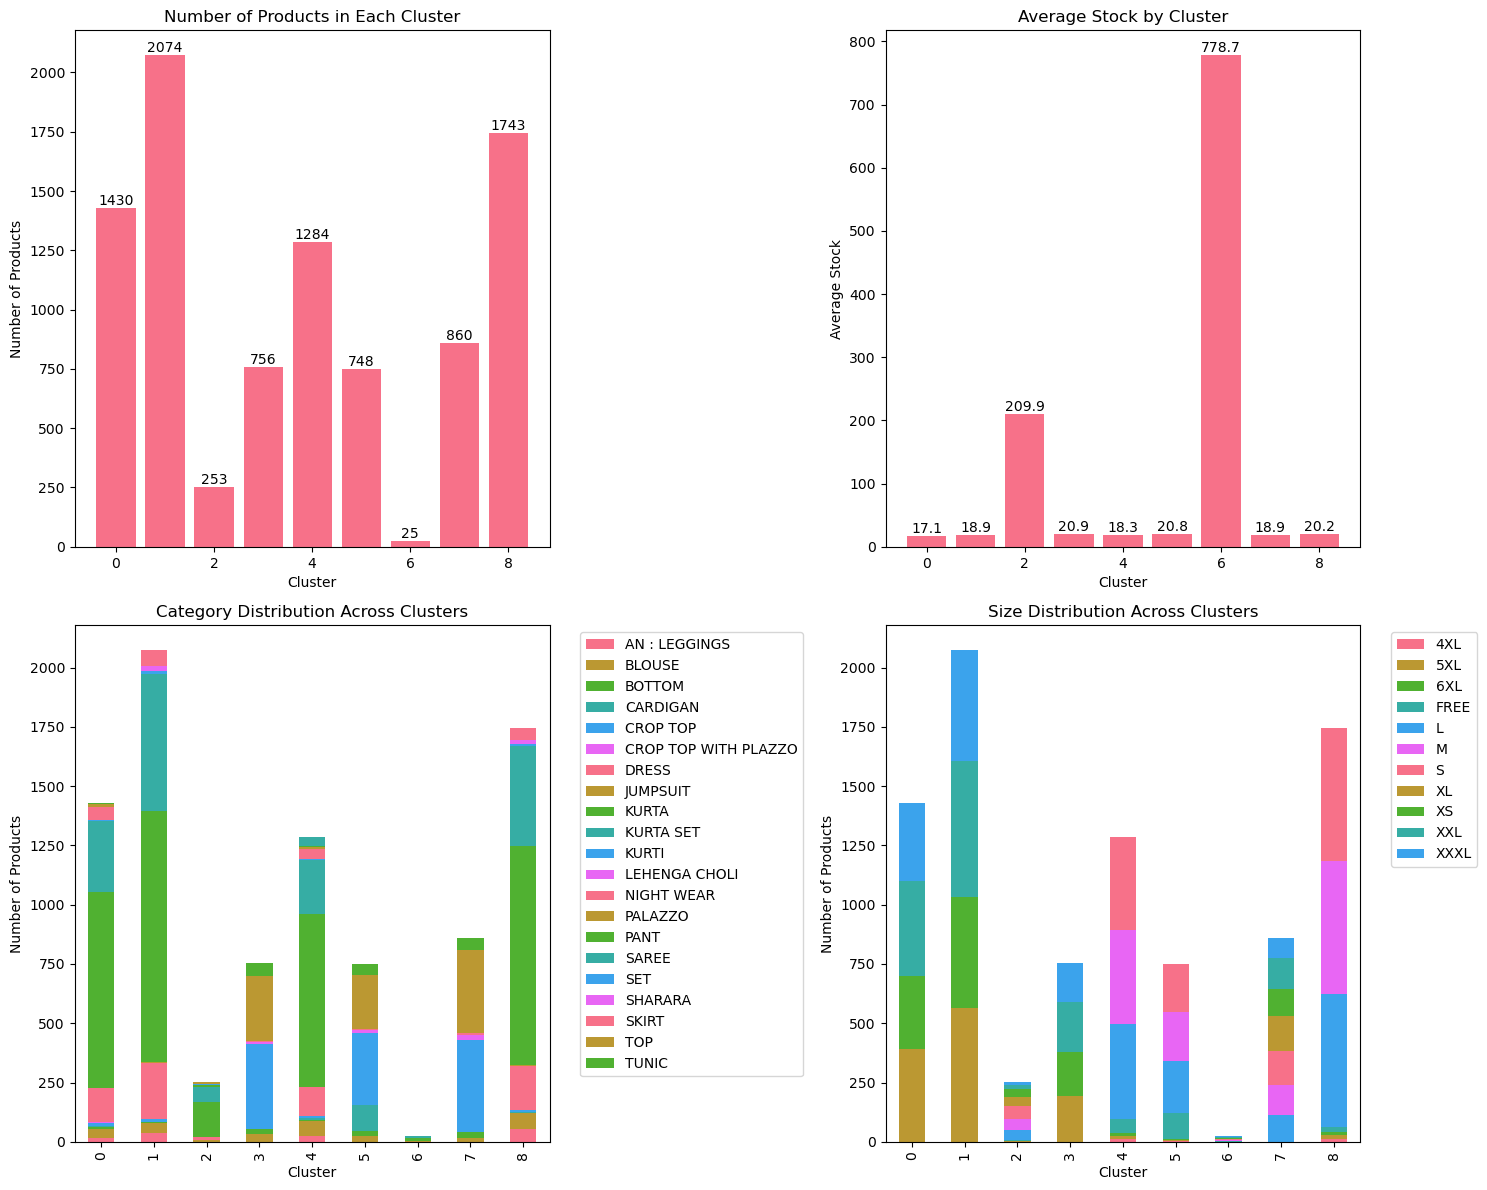


6. ADVANCED SEGMENTATION VISUALIZATION


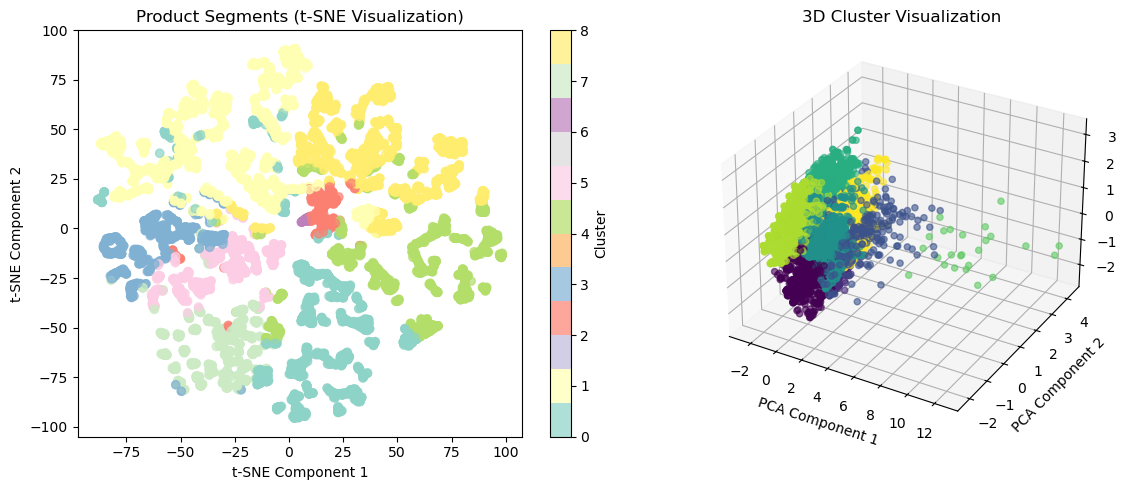


7. SEGMENT INTERPRETATION AND BUSINESS NAMES
Cluster 0: KURTA_XXL_Low_Stock
  - Products: 1430
  - Avg Stock: 17.1
  - Dominant Category: KURTA
  - Dominant Size: XXL
  - Top Colors: Blue, Black, Green

Cluster 1: KURTA_XXL_Low_Stock
  - Products: 2074
  - Avg Stock: 18.9
  - Dominant Category: KURTA
  - Dominant Size: XXL
  - Top Colors: Pink, Peach, Teal

Cluster 2: KURTA_S_High_Stock
  - Products: 253
  - Avg Stock: 209.9
  - Dominant Category: KURTA
  - Dominant Size: S
  - Top Colors: Blue, Navy Blue, Mustard

Cluster 3: SET_XXL_Low_Stock
  - Products: 756
  - Avg Stock: 20.9
  - Dominant Category: SET
  - Dominant Size: XXL
  - Top Colors: Pink, Maroon, White

Cluster 4: KURTA_L_Low_Stock
  - Products: 1284
  - Avg Stock: 18.3
  - Dominant Category: KURTA
  - Dominant Size: L
  - Top Colors: Blue, Black, Green

Cluster 5: SET_L_Low_Stock
  - Products: 748
  - Avg Stock: 20.8
  - Dominant Category: SET
  - Dominant Size: L
  - Top Colors: Pink, Maroon, White

Cluster 6: KURTA_XS_

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

print("=== PRODUCT SEGMENTATION USING MACHINE LEARNING ===\n")

# 1. DATA PREPARATION FOR SEGMENTATION
print("1. DATA PREPARATION")

# Select features for segmentation
segmentation_data = df.copy()

# Convert categorical variables to numerical using Label Encoding
categorical_cols = ['Category', 'Size', 'Color']
label_encoders = {}

for col in categorical_cols:
    if col in segmentation_data.columns:
        le = LabelEncoder()
        segmentation_data[col + '_encoded'] = le.fit_transform(segmentation_data[col].astype(str))
        label_encoders[col] = le

# Ensure Stock is numeric
segmentation_data['Stock'] = pd.to_numeric(segmentation_data['Stock'], errors='coerce')

# Select features for clustering
feature_cols = ['Stock', 'Category_encoded', 'Size_encoded', 'Color_encoded']
X = segmentation_data[feature_cols].fillna(0)

print(f"Features used for segmentation: {feature_cols}")
print(f"Data shape for clustering: {X.shape}")

# 2. FEATURE SCALING
print("\n2. FEATURE SCALING")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Features scaled successfully")

# 3. DETERMINE OPTIMAL NUMBER OF CLUSTERS
print("\n3. FINDING OPTIMAL NUMBER OF CLUSTERS")

# Elbow Method
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)

# Silhouette Score
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.grid(True)

# 4. APPLY K-MEANS CLUSTERING WITH OPTIMAL K
optimal_k = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
print(f"Optimal number of clusters: {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)
segmentation_data['Cluster'] = cluster_labels

# 5. DIMENSIONALITY REDUCTION FOR VISUALIZATION
print("\n4. DIMENSIONALITY REDUCTION AND VISUALIZATION")

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE for better visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Add reduced dimensions to dataframe
segmentation_data['PCA1'] = X_pca[:, 0]
segmentation_data['PCA2'] = X_pca[:, 1]
segmentation_data['TSNE1'] = X_tsne[:, 0]
segmentation_data['TSNE2'] = X_tsne[:, 1]

# Plot clustering results
plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title(f'Product Segments (K-means, k={optimal_k})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 6. CLUSTER ANALYSIS AND PROFILING
print("\n5. CLUSTER PROFILING")

# Create detailed cluster profiles
cluster_profiles = segmentation_data.groupby('Cluster').agg({
    'Stock': ['mean', 'median', 'count'],
    'Category': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'Size': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown',
    'Color': lambda x: x.mode()[0] if len(x.mode()) > 0 else 'Unknown'
}).round(2)

cluster_profiles.columns = ['Avg_Stock', 'Median_Stock', 'Product_Count', 
                           'Dominant_Category', 'Dominant_Size', 'Dominant_Color']
cluster_profiles = cluster_profiles.reset_index()

print("Cluster Profiles:")
print(cluster_profiles)

# 7. VISUALIZE CLUSTER CHARACTERISTICS
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Cluster sizes
cluster_sizes = segmentation_data['Cluster'].value_counts().sort_index()
axes[0,0].bar(cluster_sizes.index, cluster_sizes.values)
axes[0,0].set_title('Number of Products in Each Cluster')
axes[0,0].set_xlabel('Cluster')
axes[0,0].set_ylabel('Number of Products')
for i, v in enumerate(cluster_sizes.values):
    axes[0,0].text(i, v, str(v), ha='center', va='bottom')

# Average stock by cluster
avg_stock_by_cluster = segmentation_data.groupby('Cluster')['Stock'].mean()
axes[0,1].bar(avg_stock_by_cluster.index, avg_stock_by_cluster.values)
axes[0,1].set_title('Average Stock by Cluster')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Average Stock')
for i, v in enumerate(avg_stock_by_cluster.values):
    axes[0,1].text(i, v, f'{v:.1f}', ha='center', va='bottom')

# Category distribution across clusters
category_cluster = pd.crosstab(segmentation_data['Cluster'], segmentation_data['Category'])
category_cluster.plot(kind='bar', ax=axes[1,0], stacked=True)
axes[1,0].set_title('Category Distribution Across Clusters')
axes[1,0].set_xlabel('Cluster')
axes[1,0].set_ylabel('Number of Products')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Size distribution across clusters
size_cluster = pd.crosstab(segmentation_data['Cluster'], segmentation_data['Size'])
size_cluster.plot(kind='bar', ax=axes[1,1], stacked=True)
axes[1,1].set_title('Size Distribution Across Clusters')
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Number of Products')
axes[1,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 8. ADVANCED SEGMENTATION VISUALIZATION
print("\n6. ADVANCED SEGMENTATION VISUALIZATION")

# t-SNE visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, cmap='Set3', alpha=0.7)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title(f'Product Segments (t-SNE Visualization)')
plt.colorbar(scatter, label='Cluster')

# 3D visualization using first three PCA components
from mpl_toolkits.mplot3d import Axes3D

pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

ax = plt.subplot(1, 2, 2, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], 
                    c=cluster_labels, cmap='viridis', alpha=0.6)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D Cluster Visualization')

plt.tight_layout()
plt.show()

# 9. SEGMENT INTERPRETATION AND BUSINESS NAMING
print("\n7. SEGMENT INTERPRETATION AND BUSINESS NAMES")

# Define segment names based on characteristics
segment_names = {}
for cluster_id in range(optimal_k):
    cluster_data = segmentation_data[segmentation_data['Cluster'] == cluster_id]
    
    # Determine segment characteristics
    dominant_category = cluster_data['Category'].mode()[0]
    avg_stock = cluster_data['Stock'].mean()
    dominant_size = cluster_data['Size'].mode()[0]
    
    # Create business-friendly segment names
    if avg_stock > segmentation_data['Stock'].mean():
        stock_level = "High_Stock"
    else:
        stock_level = "Low_Stock"
    
    segment_name = f"{dominant_category}_{dominant_size}_{stock_level}"
    segment_names[cluster_id] = segment_name
    
    print(f"Cluster {cluster_id}: {segment_name}")
    print(f"  - Products: {len(cluster_data)}")
    print(f"  - Avg Stock: {avg_stock:.1f}")
    print(f"  - Dominant Category: {dominant_category}")
    print(f"  - Dominant Size: {dominant_size}")
    print(f"  - Top Colors: {', '.join(cluster_data['Color'].value_counts().head(3).index.tolist())}")
    print()

# 10. RECOMMENDATIONS BASED ON SEGMENTS
print("\n8. BUSINESS RECOMMENDATIONS")

high_stock_clusters = cluster_profiles[cluster_profiles['Avg_Stock'] > cluster_profiles['Avg_Stock'].mean()]
low_stock_clusters = cluster_profiles[cluster_profiles['Avg_Stock'] <= cluster_profiles['Avg_Stock'].mean()]

print("High Stock Segments (Consider promotions):")
for _, cluster in high_stock_clusters.iterrows():
    print(f"  - Cluster {cluster['Cluster']}: {cluster['Dominant_Category']} in {cluster['Dominant_Size']}")

print("\nLow Stock Segments (Consider restocking):")
for _, cluster in low_stock_clusters.iterrows():
    print(f"  - Cluster {cluster['Cluster']}: {cluster['Dominant_Category']} in {cluster['Dominant_Size']}")

# 11. EXPORT SEGMENTED DATA
segmentation_data['Segment_Name'] = segmentation_data['Cluster'].map(segment_names)
output_file = "product_segments_with_clusters.xlsx"
segmentation_data.to_excel(output_file, index=False)
print(f"\nSegmented data exported to: {output_file}")

print("\n=== PRODUCT SEGMENTATION ANALYSIS COMPLETE ===")